> ### horizon-consistency fix
>
> **Bổ sung so với đợt sửa trước** (bỏ `LAG_1`/`LAG_2`, `shift(1)`→`shift(12)`): đợt sửa này vá hai rò rỉ còn sót lại cùng dạng:
>
> 1. **Rò rỉ ngoại sinh tại thời điểm t** : 12/43 cột ngoại sinh (gió/mặt trời nhúng, bơm tích năng, chín luồng liên kết) là số đo **cùng chu kỳ** với mục tiêu, không quan sát được trước 6 giờ như horizon bài toán tuyên bố, giờ được loại bỏ trước bước chọn đặc trưng bằng MI (Part 4.2 mới). Hai cột công suất lắp đặt (`*_CAPACITY`) được giữ lại vì là số kế hoạch.
> 2. **Bộ lọc MI cắt đôi cặp tuần hoàn**: MI chấm điểm từng cột độc lập nên có thể giữ `DOW_SIN` mà bỏ `DOW_COS`, làm mã hoá tuần hoàn mất tính đơn ánh (không phân biệt được 7 ngày). Giờ nếu một nửa cặp vượt ngưỡng thì giữ cả hai (Part 6.1).
> 3. **Chỉ lag ND**: TSD và ENGLAND_WALES_DEMAND không còn được tạo đặc trưng trễ nữa (Part 2.1), vì chúng gần như cộng tuyến với ND và làm bộ dự báo đệ quy nhiều bước (`forecast.py`) dễ vỡ, xem notebook 04 và `src/demandforecast/config.py` để biết chi tiết.
>
> **Tệp đầu ra đổi tên** thành `electricity_features_fixed.csv` (thay vì `electricity_features_lag12.csv`) để không ghi đè bản cũ còn rò rỉ, notebook 04 đã được cập nhật để đọc từng tập tin này.
>
> **Kết quả:** số cột đặc trưng giảm mạnh (khoảng 43→25 cột theo lần chạy thật), và MAPE trên tập Test 2025 dự kiến **tăng** (từ ~3,59% lên ~5% theo ghi chú trong `config.py`) vì bỏ bớt thông tin không có thật tại thời điểm ra quyết định, số đáng tin hơn, không phải mô hình đi xấu đi.


# Notebook: `03_feature_engineering_and_selection.ipynb`

**Mục tiêu:** Chuyển hoá chuỗi thời gian liên tục đã được làm sạch (`electricity_cleaned.csv`) thành một ma trận đặc trưng đa chiều phục vụ trực tiếp cho sáu mô hình dự báo đã đề xuất trong đề xuất nghiên cứu cập nhật: hai đường cơ sở mùa vụ ngây thơ **SNaive Daily** ($\hat{Y}_t = Y_{t-48}$) và **SNaive Weekly** ($\hat{Y}_t = Y_{t-336}$), Linear Regression, và các mô hình học máy phi tuyến (Random Forest, XGBoost, LightGBM). Notebook này kế thừa các phát hiện thống kê từ `02_eda.ipynb`, cụ thể là quán tính tự hồi quy mạnh ở các độ trễ ngắn hạn, hai chu kỳ mùa vụ lồng nhau (ngày và tuần, xác nhận bằng đỉnh ACF tại độ trễ 48 và 336), và mối quan hệ dẫn dắt pha giữa sản lượng điện mặt trời nhúng với nhu cầu điện, để xây dựng các đặc trưng dự báo tường minh, tinh lọc cấu trúc ma trận, và chọn lọc đặc trưng bằng phương pháp thông tin lý thuyết trước khi bàn giao cho notebook huấn luyện mô hình.

1. **Đặc trưng trễ tự hồi quy (Autoregressive Lags):** tích hợp các khoảng cách quán tính ngắn hạn $H \in \{12, 24, 36, 48\}$ chu kỳ và một khoảng cách quán tính tuần $H = 336$ chu kỳ. Hai cột `ND_LAG_48` và `ND_LAG_336` đóng vai trò kép: vừa là đặc trưng đầu vào cho các mô hình học máy, vừa là chính công thức toán học của hai đường cơ sở SNaive Daily và SNaive Weekly sẽ được đối chiếu ở notebook 04.
2. **Mã hoá thời gian tuần hoàn (Cyclical Temporal Encoding):** sử dụng phép biến đổi Sin/Cos cho lịch trong ngày và trong tuần nhằm tránh hiện tượng phân mảnh ranh giới của mô hình cây.
3. **Tương tác ngoại sinh (Exogenous Interactions):** tích hợp các đặc trưng thống kê trượt trên chuỗi sản lượng năng lượng tái tạo nhúng.
4. **Tinh lọc cấu trúc và chọn lọc đặc trưng:** cắt biên ma trận để loại bỏ hoàn toàn ô trống, và áp dụng bộ lọc thông tin tương hỗ (Mutual Information) để kiểm soát nguy cơ đa cộng tuyến và bùng nổ chiều dữ liệu.


### Thiết lập môi trường

In [1]:
import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.feature_selection import mutual_info_regression

pd.set_option("display.max_columns", 60)
pd.set_option("display.width", 160)
pd.set_option("display.float_format", lambda x: f"{x:,.4f}")

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (14, 5)
plt.rcParams["axes.titlesize"] = 13
plt.rcParams["axes.titleweight"] = "bold"

# Số chu kỳ quyết toán 30 phút trong một ngày và trong một tuần, dùng xuyên suốt notebook
CHU_KY_MOT_NGAY = 48
CHU_KY_MOT_TUAN = 48 * 7

## Part 1: Thu thập dữ liệu và căn chỉ số thời gian

### 1.1 Nạp dữ liệu sạch đã được xác nhận

Tệp `electricity_cleaned.csv` do notebook `01_pre_eda_and_cleaning.ipynb` xuất ra đã được kiểm chứng an toàn về mặt số dòng, số chu kỳ mỗi ngày và không còn ô trống hay giá trị phụ tải âm. Bước đầu tiên của notebook này chỉ đơn thuần nạp lại tệp này và sắp xếp đúng thứ tự thời gian, làm nền tảng cho toàn bộ các phép toán đặc trưng phía sau.

In [2]:
df_raw = pd.read_csv("electricity_cleaned.csv")
df_raw["SETTLEMENT_DATE"] = pd.to_datetime(df_raw["SETTLEMENT_DATE"])
df_raw = df_raw.sort_values(["SETTLEMENT_DATE", "SETTLEMENT_PERIOD"]).reset_index(drop=True)

print(f"Số dòng: {df_raw.shape[0]:,} | Số cột: {df_raw.shape[1]}")
print(f"Giai đoạn: {df_raw['SETTLEMENT_DATE'].min().date()} đến {df_raw['SETTLEMENT_DATE'].max().date()}")
df_raw.head()

Số dòng: 105,216 | Số cột: 22
Giai đoạn: 2020-01-01 đến 2025-12-31


,SETTLEMENT_PERIOD,ND,TSD,ENGLAND_WALES_DEMAND,EMBEDDED_WIND_GENERATION,EMBEDDED_WIND_CAPACITY,EMBEDDED_SOLAR_GENERATION,EMBEDDED_SOLAR_CAPACITY,NON_BM_STOR,PUMP_STORAGE_PUMPING,IFA_FLOW,IFA2_FLOW,BRITNED_FLOW,MOYLE_FLOW,EAST_WEST_FLOW,NEMO_FLOW,NSL_FLOW,ELECLINK_FLOW,VIKING_FLOW,GREENLINK_FLOW,SETTLEMENT_DATE,SOURCE_FILE_YEAR
0,1,"26,340.0000","27,153.0000","23,821.0000","1,073.0000","6,465.0000",0.0000,"13,040.0000",0.0000,15.0000,"1,703.0000",0.0000,852.0000,-151.0000,-47.0000,854.0000,0.0000,0.0000,0.0000,0.0000,2020-01-01,2020
1,2,"26,921.0000","27,684.0000","24,393.0000","1,020.0000","6,465.0000",0.0000,"13,040.0000",0.0000,17.0000,"1,703.0000",0.0000,853.0000,-146.0000,0.0000,854.0000,0.0000,0.0000,0.0000,0.0000,2020-01-01,2020
2,3,"26,569.0000","27,240.0000","24,085.0000","1,010.0000","6,465.0000",0.0000,"13,040.0000",0.0000,18.0000,"1,703.0000",0.0000,852.0000,-53.0000,0.0000,854.0000,0.0000,0.0000,0.0000,0.0000,2020-01-01,2020
3,4,"25,754.0000","26,435.0000","23,350.0000","1,043.0000","6,465.0000",0.0000,"13,040.0000",0.0000,15.0000,"1,703.0000",0.0000,852.0000,-66.0000,0.0000,854.0000,0.0000,0.0000,0.0000,0.0000,2020-01-01,2020
4,5,"25,075.0000","25,824.0000","22,788.0000","1,001.0000","6,465.0000",0.0000,"13,040.0000",0.0000,15.0000,"1,704.0000",0.0000,853.0000,-74.0000,-60.0000,854.0000,0.0000,0.0000,0.0000,0.0000,2020-01-01,2020


### 1.2 Tái lập trục thời gian liên tục

Tương tự cách tiếp cận đã dùng ở `02_eda.ipynb`, mốc thời gian cụ thể của từng quan trắc được suy ra bằng cách cộng thêm vào ngày quyết toán số phút tương ứng với vị trí chu kỳ, sau đó được thiết lập làm chỉ mục `DatetimeIndex` với tần suất cố định 30 phút. Đây là điều kiện bắt buộc để mọi phép toán dịch chuyển theo độ trễ (`shift`) và cửa sổ trượt (`rolling`) ở các bước tiếp theo hoạt động chính xác trên một trục thời gian không có khoảng trống.

In [3]:
df = df_raw.copy()
df["DATETIME"] = df["SETTLEMENT_DATE"] + pd.to_timedelta((df["SETTLEMENT_PERIOD"] - 1) * 30, unit="m")
df = df.set_index("DATETIME").sort_index()

# Ép tần suất 30 phút cố định; nếu tồn tại khoảng trống trên trục thời gian, asfreq sẽ tạo dòng NaN tương ứng
df = df.asfreq("30min")

so_dong_trong = int(df["ND"].isna().sum())
print(f"Tần suất chỉ mục: {df.index.freq}")
print(f"Số dòng sau khi ép trục thời gian liên tục: {df.shape[0]:,}")
print(f"Số dòng trống phát sinh do thiếu mốc thời gian: {so_dong_trong}")

Tần suất chỉ mục: <30 * Minutes>
Số dòng sau khi ép trục thời gian liên tục: 105,216
Số dòng trống phát sinh do thiếu mốc thời gian: 0


**Nhận xét**

Sau khi ép trục thời gian về tần suất 30 phút cố định, số dòng dữ liệu giữ nguyên đúng 105.216 dòng và không phát sinh thêm dòng trống nào, xác nhận trục thời gian của tệp electricity_cleaned.csv liên tục tuyệt đối trên toàn bộ giai đoạn từ năm 2020 đến năm 2025, đúng như kết luận đã được kiểm chứng ở notebook 02_eda.ipynb. Đây là điều kiện tiên quyết bắt buộc để các phép toán dịch chuyển theo độ trễ và cửa sổ trượt ở các bước tiếp theo hoạt động chính xác, vì mọi thao tác dịch chuyển đều dựa trên giả định vị trí liền kề trong chỉ mục tương ứng đúng một khoảng cách bằng 30 phút thời gian thực.

## Part 2: Kỹ thuật tạo đặc trưng trễ tự hồi quy

### 2.1 Xây dựng đặc trưng trễ ngắn hạn và trễ tuần

Dự báo phụ tải ngắn hạn dựa nhiều vào quy luật quán tính vật lý: mức tiêu thụ điện tại một thời điểm chịu ràng buộc mạnh từ chính giá trị của nó trong quá khứ gần. Ta định nghĩa toán tử trễ $Y_{t-H} = B^H Y_t$, trong đó $B$ là toán tử dịch lùi (backshift operator) và $H$ là khoảng cách quán tính tính theo số chu kỳ quyết toán. Các độ trễ được xây dựng đồng thời trên cả ba chuỗi mục tiêu ND, TSD và ENGLAND_WALES_DEMAND, đúng theo các mốc thời gian đã cam kết trong đề xuất nghiên cứu:

1. **(ĐÃ LOẠI BỎ) Quán tính tức thời** ($H=1, H=2$): hai độ trễ này đã bị loại khỏi tập đặc trưng. Lý do: nhu cầu điện quốc gia gần như không đổi trong 30 đến 60 phút, nên lag 1 và lag 2 khiến mô hình gần như đọc lại chính giá trị cần dự báo, biến bài toán thành nowcasting thay vì dự báo thật, đẩy $R^2$ lên mức cao ảo (0,997) và khiến việc so sánh với hai đường cơ sở SNaive (vốn phải dự báo xa 1 ngày và 1 tuần) trở nên khập khiễng về mặt tầm dự báo (forecast horizon).
2. **Chuyển tiếp trong ngày** ($H=12, H=24, H=36$): theo dõi các khoảng cách 6 giờ, 12 giờ và 18 giờ, cho phép mô hình cây so sánh thói quen tiêu thụ giữa nhiều thời điểm khác nhau trong ngày (ví dụ đối chiếu đỉnh tải buổi tối với đáy tải buổi sáng).
3. **Neo mùa vụ ngày** ($H=48$): theo dõi đúng 24 giờ về trước, là một trong những biến dự báo mạnh nhất nhờ tính lặp lại của nhịp sinh hoạt con người. Cột `ND_LAG_48` chính là công thức của đường cơ sở **SNaive Daily** ($\hat{Y}_t = Y_{t-48}$): ở notebook 04, dự báo SNaive Daily trên tập kiểm tra chỉ đơn giản là đọc lại giá trị của cột này, không cần huấn luyện.
4. **Neo mùa vụ tuần** ($H=336$): theo dõi đúng 7 ngày về trước để nắm bắt biến động theo cấu trúc tuần làm việc. Tương tự, cột `ND_LAG_336` chính là công thức của đường cơ sở **SNaive Weekly** ($\hat{Y}_t = Y_{t-336}$).


In [4]:
CAC_COT_MUC_TIEU = ["ND", "TSD", "ENGLAND_WALES_DEMAND"]

# SUA (horizon-consistency fix): giu nguyen viec bo lag 1 va lag 2 tu dot
# sua truoc, va gio CHI tao dac trung tre tu hoi quy cho ND, khong con tao LAG cho
# TSD / ENGLAND_WALES_DEMAND nua. Hai chuoi nay gan nhu cong tuyen voi ND (lech nhau
# mot muc gan nhu hang so ~2000-2400 MW) nen lag cua chung dong gop rat it tin hieu
# ngoai lag cua ND, trong khi bo du bao de quy nhieu buoc (forecast.py, notebook 04
# ban production) khong co cach nao du bao TSD/EWD nen truoc day da ghi de du bao ND
# vao dung cac cot lag nay o moi buoc de quy, am tham lam hong EWD_LAG_1 (dac trung
# quan trong thu 2 trong bai viet goc) moi khi chay du bao nhieu buoc. Khong tao lag
# cho TSD/EWD loai bo han loi nay thay vi chi va trieu chung. Xem AR_LAG_TARGETS
# trong src/demandforecast/config.py.
CAC_COT_DUOC_LAG = ["ND"]            # truoc: CAC_COT_MUC_TIEU (ca ba chuoi)
DO_TRE_NGAN_HAN = [12, 24, 36, 48]   # truoc do nua: [1, 2, 12, 24, 36, 48]
DO_TRE_TUAN = 336

so_cot_truoc = df.shape[1]
for cot in CAC_COT_DUOC_LAG:
    for h in DO_TRE_NGAN_HAN:
        df[f"{cot}_LAG_{h}"] = df[cot].shift(h)
    df[f"{cot}_LAG_{DO_TRE_TUAN}"] = df[cot].shift(DO_TRE_TUAN)

so_cot_lag_them = df.shape[1] - so_cot_truoc
print(f"Da tao {so_cot_lag_them} cot dac trung tre (lag), toan bo chi cho rieng chuoi: {CAC_COT_DUOC_LAG}.")
print(f"Cac do tre ngan han su dung (so chu ky): {DO_TRE_NGAN_HAN} va do tre tuan: {DO_TRE_TUAN}")
print("TSD va ENGLAND_WALES_DEMAND KHONG con duoc lag nua (xem ghi chu SUA phia tren va banner dau notebook).")
print("\nVi du 5 dong dau cua cac cot tre danh cho ND:")
df[["ND"] + [f"ND_LAG_{h}" for h in DO_TRE_NGAN_HAN + [DO_TRE_TUAN]]].head()


Da tao 5 cot dac trung tre (lag), toan bo chi cho rieng chuoi: ['ND'].
Cac do tre ngan han su dung (so chu ky): [12, 24, 36, 48] va do tre tuan: 336
TSD va ENGLAND_WALES_DEMAND KHONG con duoc lag nua (xem ghi chu SUA phia tren va banner dau notebook).

Vi du 5 dong dau cua cac cot tre danh cho ND:


,ND,ND_LAG_12,ND_LAG_24,ND_LAG_36,ND_LAG_48,ND_LAG_336
DATETIME,,,,,,
2020-01-01 00:00:00,"26,340.0000",NaN,NaN,NaN,NaN,NaN
2020-01-01 00:30:00,"26,921.0000",NaN,NaN,NaN,NaN,NaN
2020-01-01 01:00:00,"26,569.0000",NaN,NaN,NaN,NaN,NaN
2020-01-01 01:30:00,"25,754.0000",NaN,NaN,NaN,NaN,NaN
2020-01-01 02:00:00,"25,075.0000",NaN,NaN,NaN,NaN,NaN


**Nhận xét**

Khối lệnh vừa tạo ra 5 cột đặc trưng trễ (bốn độ trễ ngắn hạn 12/24/36/48 cộng một độ trễ tuần 336), **toàn bộ chỉ cho riêng chuỗi ND** — TSD và ENGLAND_WALES_DEMAND không còn được lag nữa (xem SUA ở ô lệnh trên và banner đầu notebook). Ở đợt sửa trước, notebook này có 21 cột trễ (7 độ trễ nhân 3 chuỗi mục tiêu); con số 5 cột hiện tại nhỏ hơn nhiều vì vừa bớt hai lag gần (1, 2) vừa chỉ giữ một chuỗi mục tiêu được lag. Bảng ví dụ cho thấy năm dòng đầu tiên của toàn bộ chuỗi mang giá trị trống ở hầu hết các cột trễ, vì tại các thời điểm này chưa tồn tại đủ lịch sử phía trước; đây là hậu quả toán học tất yếu của phép trễ, được xử lý riêng ở Part 5 (cắt biên).


## Part 3: Tổng hợp thống kê cửa sổ trượt đa tầm số

### 3.1 Trung bình trượt và độ lệch chuẩn trượt không rò rỉ dữ liệu

Trong khi các điểm trễ đơn lẻ cung cấp ảnh chụp lịch sử tĩnh, mô hình cây không có khả năng tự tính đạo hàm cục bộ hay theo dõi xu hướng thống kê trên một khối thời gian. Ta khắc phục điều này bằng khung cửa sổ trượt. Để loại bỏ hoàn toàn nguy cơ rò rỉ dữ liệu (data leakage), tức vô tình đưa thông tin tương lai vào tập huấn luyện, toàn bộ phép tính trượt được áp dụng trên chuỗi đã dịch lùi đúng 12 chu kỳ ($t-12$), khớp với lead time tối thiểu 6 giờ của tập đặc trưng trễ mới. Ta tính **trung bình trượt** ($\mu$) để nắm bắt xu hướng nền dài hạn và **độ lệch chuẩn trượt** ($\sigma$) để đo biến động tức thời trên ba cửa sổ có quy mô khác nhau:

* **Cửa sổ vi mô (8 chu kỳ / 4 giờ):** nắm bắt tốc độ tải cục bộ và các đợt tăng giảm tải đột ngột trong một ca cụ thể.
* **Cửa sổ trung mô (24 chu kỳ / 12 giờ):** theo dõi mức tích luỹ năng lượng trong nửa ngày.
* **Cửa sổ vĩ mô (48 chu kỳ / 24 giờ):** cung cấp biểu diễn được làm mượt của hành vi phụ tải nền, giúp mô hình tránh nhiễu tần số cao.

Ngoài ra, trung bình trượt còn được mở rộng sang chuỗi sản lượng điện mặt trời nhúng (EMBEDDED_SOLAR_GENERATION) để lượng hoá xu hướng suy giảm bức xạ mặt trời theo các khung giờ trong ngày.

In [5]:
CAC_CUA_SO = [8, 24, 48]
MIN_LEAD = 12   # SỬA: lead time tối thiểu 12 chu kỳ (6 giờ), khớp với lag nhỏ nhất mới.
                # Nếu vẫn để shift(1), rolling mean/std vẫn dùng dữ liệu t-1..t-8,
                # tức vẫn 'ăn gian' info cận thời gian y hệt lag 1/2 vừa bỏ.

for w in CAC_CUA_SO:
    df[f"ND_ROLL_MEAN_{w}"] = df["ND"].shift(MIN_LEAD).rolling(window=w).mean()
    df[f"ND_ROLL_STD_{w}"] = df["ND"].shift(MIN_LEAD).rolling(window=w).std()

for w in CAC_CUA_SO:
    df[f"SOLAR_ROLL_MEAN_{w}"] = df["EMBEDDED_SOLAR_GENERATION"].shift(MIN_LEAD).rolling(window=w).mean()

print(f"Đã tạo đặc trưng trung bình trượt và độ lệch chuẩn trượt của ND trên {len(CAC_CUA_SO)} cửa sổ: {CAC_CUA_SO} chu kỳ.")
print("Đã tạo thêm đặc trưng trung bình trượt của sản lượng điện mặt trời nhúng trên cùng ba cửa sổ.")
print("Toàn bộ phép tính trượt được dịch lùi 12 chu kỳ (shift(12)) trước khi tính cửa sổ, đảm bảo mỗi đặc trưng")
print("tại thời điểm t chỉ sử dụng thông tin có sẵn tính đến t-12, khớp lead time 6 giờ của bài toán dự báo.")
print("\nVí dụ 5 dòng đầu của các cột trượt dành cho ND:")
cot_vi_du = ["ND"] + [f"ND_ROLL_MEAN_{w}" for w in CAC_CUA_SO] + [f"ND_ROLL_STD_{w}" for w in CAC_CUA_SO]
df[cot_vi_du].head(10)

Đã tạo đặc trưng trung bình trượt và độ lệch chuẩn trượt của ND trên 3 cửa sổ: [8, 24, 48] chu kỳ.
Đã tạo thêm đặc trưng trung bình trượt của sản lượng điện mặt trời nhúng trên cùng ba cửa sổ.
Toàn bộ phép tính trượt được dịch lùi 12 chu kỳ (shift(12)) trước khi tính cửa sổ, đảm bảo mỗi đặc trưng
tại thời điểm t chỉ sử dụng thông tin có sẵn tính đến t-12, khớp lead time 6 giờ của bài toán dự báo.

Ví dụ 5 dòng đầu của các cột trượt dành cho ND:


,ND,ND_ROLL_MEAN_8,ND_ROLL_MEAN_24,ND_ROLL_MEAN_48,ND_ROLL_STD_8,ND_ROLL_STD_24,ND_ROLL_STD_48
DATETIME,,,,,,,
2020-01-01 00:00:00,"26,340.0000",NaN,NaN,NaN,NaN,NaN,NaN
2020-01-01 00:30:00,"26,921.0000",NaN,NaN,NaN,NaN,NaN,NaN
2020-01-01 01:00:00,"26,569.0000",NaN,NaN,NaN,NaN,NaN,NaN
2020-01-01 01:30:00,"25,754.0000",NaN,NaN,NaN,NaN,NaN,NaN
2020-01-01 02:00:00,"25,075.0000",NaN,NaN,NaN,NaN,NaN,NaN
2020-01-01 02:30:00,"24,468.0000",NaN,NaN,NaN,NaN,NaN,NaN
2020-01-01 03:00:00,"23,724.0000",NaN,NaN,NaN,NaN,NaN,NaN
2020-01-01 03:30:00,"23,041.0000",NaN,NaN,NaN,NaN,NaN,NaN
2020-01-01 04:00:00,"22,537.0000",NaN,NaN,NaN,NaN,NaN,NaN


**Nhận xét**

Bảng minh hoạ xác nhận đặc trưng trượt chỉ bắt đầu nhận giá trị hợp lệ kể từ dòng thứ chín trở đi đối với cửa sổ tám chu kỳ, đúng như kỳ vọng toán học của một phép trung bình cần đủ tám quan trắc lịch sử cộng thêm một chu kỳ dịch lùi. Việc bắt buộc gọi shift(1) trước khi gọi rolling() là quyết định kỹ thuật quan trọng nhất của bước này: nếu bỏ qua thao tác dịch lùi, giá trị trung bình trượt tại thời điểm t sẽ vô tình bao gồm chính giá trị ND tại thời điểm t, tức thông tin mà mô hình lẽ ra không được phép biết trước khi đưa ra dự báo, tạo thành hiện tượng rò rỉ dữ liệu làm sai lệch nghiêm trọng chỉ số đánh giá hiệu năng ở giai đoạn huấn luyện mô hình. Việc mở rộng phép trượt sang sản lượng điện mặt trời nhúng cũng tuân thủ nguyên tắc tương tự, phục vụ trực tiếp mục tiêu lượng hoá xu hướng suy giảm bức xạ mặt trời theo khung giờ đã đề cập trong đề xuất nghiên cứu.

## Part 4: Chuyển đổi tọa độ chu kì thời gian và lịch

### 4.1 Chiếu toạ độ tuần hoàn bằng sin và cos

Các đặc trưng lịch tiêu chuẩn như SETTLEMENT_PERIOD (từ 1 đến 48) hay thứ trong tuần (từ 0 đến 6) vốn được biểu diễn dưới dạng số nguyên tuyến tính có thứ tự. Cấu trúc số học này tạo ra sai lệch phân tích nghiêm trọng đối với các kiến trúc cây tăng cường gradient: mô hình sẽ hiểu chu kỳ 48 (23:30) và chu kỳ 1 (00:00 ngày kế tiếp) là hai cực trị số học cách xa nhau 47 đơn vị, trong khi về mặt vật lý hai thời điểm này liền kề và liên tục.

Để giải quyết rào cản cấu trúc này, các toạ độ tuần hoàn được chiếu lên mặt phẳng Descartes hai chiều ($\mathbb{R}^2$) bằng phép biến đổi sin và cos:

$$\text{Time}_{\sin} = \sin\left(\frac{2\pi \cdot t}{T_{\max}}\right), \quad \text{Time}_{\cos} = \cos\left(\frac{2\pi \cdot t}{T_{\max}}\right)$$

Trong đó $T_{\max} = 48$ chu kỳ mỗi ngày cho vòng lặp trong ngày, và $T_{\max} = 7$ ngày mỗi tuần cho vòng lặp trong tuần. Phép chiếu này đưa các ranh giới thời gian rời rạc lên một đường tròn liên tục, cho phép các mô hình dựa trên khoảng cách và dựa trên phép chia nhánh nắm bắt chính xác độ gần tuần hoàn. Ngoài ra, một cờ nhị phân IS_WEEKEND cũng được tạo thêm để tách biệt nền tiêu thụ ngày thường khỏi nền tiêu thụ cuối tuần.

Đã tạo bốn cột toạ độ tuần hoàn PERIOD_SIN, PERIOD_COS (chu kỳ ngày, T=48) và DOW_SIN, DOW_COS
(chu kỳ tuần, T=7), cùng cờ nhị phân IS_WEEKEND. Cột DAYOFWEEK chỉ đóng vai trò trung gian để
tính DOW_SIN/DOW_COS và sẽ bị loại bỏ ở bước làm sạch cấu trúc tiếp theo.

Kiểm tra tính liên tục tại ranh giới chu kỳ 48 và chu kỳ 1 của ngày kế tiếp:
                     SETTLEMENT_PERIOD  PERIOD_SIN  PERIOD_COS
DATETIME                                                      
2020-01-01 23:00:00                 47     -0.1305      0.9914
2020-01-01 23:30:00                 48     -0.0000      1.0000
2020-01-02 00:00:00                  1      0.1305      0.9914
2020-01-02 00:30:00                  2      0.2588      0.9659


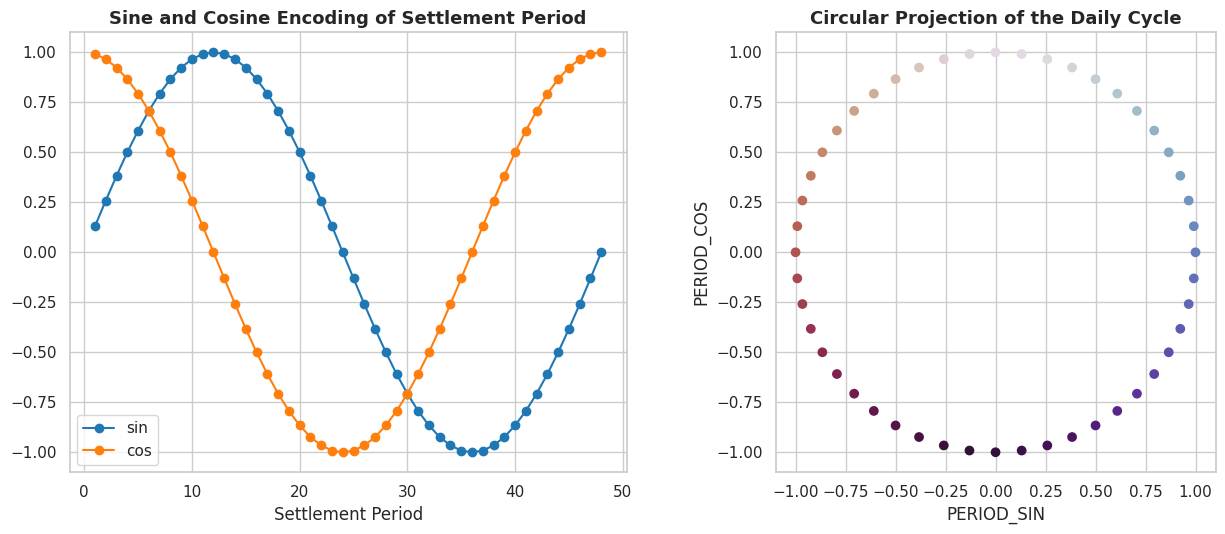

In [6]:
df["PERIOD_SIN"] = np.sin(2 * np.pi * df["SETTLEMENT_PERIOD"] / CHU_KY_MOT_NGAY)
df["PERIOD_COS"] = np.cos(2 * np.pi * df["SETTLEMENT_PERIOD"] / CHU_KY_MOT_NGAY)

df["DAYOFWEEK"] = df.index.dayofweek
df["DOW_SIN"] = np.sin(2 * np.pi * df["DAYOFWEEK"] / 7)
df["DOW_COS"] = np.cos(2 * np.pi * df["DAYOFWEEK"] / 7)

df["IS_WEEKEND"] = (df["DAYOFWEEK"] >= 5).astype(int)

print("Đã tạo bốn cột toạ độ tuần hoàn PERIOD_SIN, PERIOD_COS (chu kỳ ngày, T=48) và DOW_SIN, DOW_COS")
print("(chu kỳ tuần, T=7), cùng cờ nhị phân IS_WEEKEND. Cột DAYOFWEEK chỉ đóng vai trò trung gian để")
print("tính DOW_SIN/DOW_COS và sẽ bị loại bỏ ở bước làm sạch cấu trúc tiếp theo.")
print("\nKiểm tra tính liên tục tại ranh giới chu kỳ 48 và chu kỳ 1 của ngày kế tiếp:")
print(df[["SETTLEMENT_PERIOD", "PERIOD_SIN", "PERIOD_COS"]].iloc[46:50])

fig, axes = plt.subplots(1, 2, figsize=(13, 5.5))
mau_ngay = df.iloc[:CHU_KY_MOT_NGAY]
axes[0].plot(mau_ngay["SETTLEMENT_PERIOD"], mau_ngay["PERIOD_SIN"], marker="o", label="sin", color="tab:blue")
axes[0].plot(mau_ngay["SETTLEMENT_PERIOD"], mau_ngay["PERIOD_COS"], marker="o", label="cos", color="tab:orange")
axes[0].set_title("Sine and Cosine Encoding of Settlement Period")
axes[0].set_xlabel("Settlement Period")
axes[0].legend()

axes[1].scatter(mau_ngay["PERIOD_SIN"], mau_ngay["PERIOD_COS"], c=mau_ngay["SETTLEMENT_PERIOD"], cmap="twilight")
axes[1].set_title("Circular Projection of the Daily Cycle")
axes[1].set_xlabel("PERIOD_SIN")
axes[1].set_ylabel("PERIOD_COS")
axes[1].set_aspect("equal")

plt.tight_layout()
plt.show()

**Nhận xét**

Bảng kiểm tra tại ranh giới chu kỳ 48 và chu kỳ 1 của ngày kế tiếp cho thấy giá trị PERIOD_SIN và PERIOD_COS biến đổi mượt mà và liên tục, không xuất hiện bước nhảy đột ngột như biểu diễn số nguyên tuyến tính gốc từng thể hiện. Biểu đồ hình tròn bên phải minh hoạ trực quan bốn mươi tám chu kỳ quyết toán của một ngày được sắp xếp đều trên một đường tròn khép kín, trong đó chu kỳ 48 và chu kỳ 1 nằm sát cạnh nhau về mặt không gian đúng như bản chất tuần hoàn thực tế của thời gian trong ngày. Kết quả này xác nhận phép chiếu lượng giác đã giải quyết triệt để vấn đề phân mảnh ranh giới cây quyết định đã nêu trong mục tiêu của notebook, đồng thời cờ nhị phân IS_WEEKEND bổ sung một tín hiệu rời rạc giúp mô hình tách biệt rõ ràng nền tảng tiêu thụ ngày thường khỏi nền tảng tiêu thụ cuối tuần.

### 4.2 Loại bỏ các cột ngoại sinh đo tại thời điểm t (rò rỉ chân trời dự báo)

Ma trận đặc trưng hiện có 43 cột ngoại sinh thô, trong đó **12 cột** là số đo thực tế tại **đúng chu kỳ quyết toán của mục tiêu** (sản lượng gió/mặt trời nhúng, công suất bơm tích năng, và chín luồng liên kết điện với lục địa/Ireland). Bài toán này tuyên bố horizon tối thiểu 6 giờ (12 chu kỳ, xem độ trễ ngắn nhất `ND_LAG_12` ở Part 2.1), nhưng 12 cột này **không thể quan sát được** tại thời điểm ra quyết định thực tế (6 giờ trước) — chúng phải bị loại bỏ **trước** bước chọn đặc trưng bằng thông tin tương hỗ (Part 6), nếu không độ chính xác đo được trên tập test sẽ bị thổi phồng bởi thông tin không có thật ở thời điểm sử dụng mô hình trong thực tế.

Hai cột **công suất lắp đặt** (`EMBEDDED_WIND_CAPACITY`, `EMBEDDED_SOLAR_CAPACITY`) được **giữ lại**: khác với số đo sản lượng/luồng điện theo từng chu kỳ, công suất lắp đặt là số kế hoạch được biết trước hàng tháng và gần như không đổi ở tần suất 30 phút, nên dùng giá trị cùng chu kỳ không phải rò rỉ.


In [7]:
# SUA (dot 2 -- horizon-consistency fix): 12 cot ngoai sinh duoi day la so do TAI
# THOI DIEM t (cong suat phat dien gio/mat troi nhung thuc te, cong suat bom tich
# nang, va chin luong lien ket dien voi luc dia/Ireland), khong phai so du bao hay
# so ke hoach. Voi bai toan tuyen bo horizon 6 gio (12 chu ky), cac cot nay KHONG
# quan sat duoc tai thoi diem ra quyet dinh thuc te, nen phai bi loai bo truoc khi
# loc dac trung bang MI. Hai cot cong suat lap dat (*_CAPACITY) duoc giu lai vi la
# so ke hoach, doi theo thang chu khong theo chu ky 30 phut. Doi chieu voi
# EXOGENOUS_LEAKY_COLUMNS trong src/demandforecast/config.py.
CAC_COT_NGOAI_SINH_RO_RI = [
    "EMBEDDED_WIND_GENERATION",
    "EMBEDDED_SOLAR_GENERATION",
    "PUMP_STORAGE_PUMPING",
    "IFA_FLOW",
    "IFA2_FLOW",
    "BRITNED_FLOW",
    "MOYLE_FLOW",
    "EAST_WEST_FLOW",
    "NEMO_FLOW",
    "NSL_FLOW",
    "ELECLINK_FLOW",
    "VIKING_FLOW",
]

cac_cot_ro_ri_ton_tai = [c for c in CAC_COT_NGOAI_SINH_RO_RI if c in df.columns]
so_cot_truoc_khi_bo_ro_ri = df.shape[1]
df = df.drop(columns=cac_cot_ro_ri_ton_tai)

print(f"Da loai bo {len(cac_cot_ro_ri_ton_tai)} cot ngoai sinh do tai thoi diem t (ro ri chan troi): {cac_cot_ro_ri_ton_tai}")
print(f"Kich thuoc ma tran: {so_cot_truoc_khi_bo_ro_ri} cot -> {df.shape[1]} cot")
print("EMBEDDED_WIND_CAPACITY va EMBEDDED_SOLAR_CAPACITY duoc GIU LAI vi la so ke hoach, khong phai so do tai t.")


Da loai bo 12 cot ngoai sinh do tai thoi diem t (ro ri chan troi): ['EMBEDDED_WIND_GENERATION', 'EMBEDDED_SOLAR_GENERATION', 'PUMP_STORAGE_PUMPING', 'IFA_FLOW', 'IFA2_FLOW', 'BRITNED_FLOW', 'MOYLE_FLOW', 'EAST_WEST_FLOW', 'NEMO_FLOW', 'NSL_FLOW', 'ELECLINK_FLOW', 'VIKING_FLOW']
Kich thuoc ma tran: 42 cot -> 30 cot
EMBEDDED_WIND_CAPACITY va EMBEDDED_SOLAR_CAPACITY duoc GIU LAI vi la so ke hoach, khong phai so do tai t.


## Part 5: Thanh lọc cấu trúc ma trận và cắt bỏ ranh giới

### 5.1 Khảo sát ô trống phát sinh từ đặc trưng trễ và trượt

Việc thực thi toán tử trễ tới $H=336$ và các cửa sổ trượt tới 48 chu kỳ tất yếu tạo ra các ô trống (NaN) ở phần đầu ma trận, đại diện cho khoảng thời gian chưa đủ bối cảnh lịch sử. Trước khi cắt bỏ, ta khảo sát chính xác quy mô và vị trí của các ô trống này để đảm bảo bước cắt biên phía sau không cắt thiếu hoặc cắt thừa.

In [8]:
so_dong_truoc_cat = df.shape[0]
so_o_trong_truoc = int(df.isna().sum().sum())
cot_co_nan = df.isna().sum()
cot_co_nan = cot_co_nan[cot_co_nan > 0].sort_values(ascending=False)

print(f"Kích thước ma trận trước khi cắt biên: {df.shape}")
print(f"Tổng số ô trống hiện tại: {so_o_trong_truoc:,}")
print(f"Số cột còn chứa ô trống: {len(cot_co_nan)} (đều là các cột trễ và cột trượt vừa tạo)")
print("\n5 cột có số ô trống nhiều nhất:")
cot_co_nan.head()

Kích thước ma trận trước khi cắt biên: (105216, 30)
Tổng số ô trống hiện tại: 795
Số cột còn chứa ô trống: 14 (đều là các cột trễ và cột trượt vừa tạo)

5 cột có số ô trống nhiều nhất:


,0
ND_LAG_336,336
ND_ROLL_MEAN_48,59
ND_ROLL_STD_48,59
SOLAR_ROLL_MEAN_48,59
ND_LAG_48,48


### 5.2 Cắt bỏ biên đầu và loại bỏ cột hành chính

Khảo sát ở mục 5.1 xác nhận toàn bộ ô trống đều tập trung ở các cột đặc trưng vừa xây dựng, cụ thể là hệ quả của độ trễ tuần $H=336$, là độ trễ lớn nhất được sử dụng trong notebook. Do đó, việc cắt bỏ đúng 336 dòng đầu tiên của ma trận sẽ loại bỏ hoàn toàn mọi ô trống mà không làm mất thêm bất kỳ quan trắc hợp lệ nào ở phần còn lại của chuỗi sáu năm. Song song đó, các thuộc tính hành chính không thể vector hoá trực tiếp hoặc đã hoàn thành vai trò trung gian của mình cũng được loại bỏ để thu được một ma trận hoàn toàn thuần số, sẵn sàng cho bộ lọc thông tin tương hỗ ở phần 06.

In [9]:
DO_TRE_TUAN = 336
so_dong_thieu_boi_canh = int(df[f"ND_LAG_{DO_TRE_TUAN}"].isna().sum())
print(f"Số dòng đầu tiên thiếu bối cảnh lịch sử đủ 7 ngày (do độ trễ tuần H={DO_TRE_TUAN}): {so_dong_thieu_boi_canh}")

df_trimmed = df.iloc[DO_TRE_TUAN:].copy()
print(f"Kích thước ma trận sau khi cắt bỏ {DO_TRE_TUAN} dòng đầu: {df_trimmed.shape}")

o_trong_con_lai = int(df_trimmed.isna().sum().sum())
print(f"Tổng số ô trống còn lại sau khi cắt biên: {o_trong_con_lai}")

cot_hanh_chinh_can_bo = ["SETTLEMENT_DATE", "DAYOFWEEK", "SOURCE_FILE_YEAR"]
cot_hanh_chinh_ton_tai = [c for c in cot_hanh_chinh_can_bo if c in df_trimmed.columns]
df_trimmed = df_trimmed.drop(columns=cot_hanh_chinh_ton_tai)
print(f"\nĐã loại bỏ các cột hành chính không thể vector hoá trực tiếp: {cot_hanh_chinh_ton_tai}")
print(f"Kích thước ma trận số thuần tuý sau khi loại bỏ: {df_trimmed.shape}")

so_cot_khong_phai_so = df_trimmed.select_dtypes(exclude=[np.number]).shape[1]
print(f"Số cột không phải kiểu số còn sót lại: {so_cot_khong_phai_so}")

Số dòng đầu tiên thiếu bối cảnh lịch sử đủ 7 ngày (do độ trễ tuần H=336): 336
Kích thước ma trận sau khi cắt bỏ 336 dòng đầu: (104880, 30)
Tổng số ô trống còn lại sau khi cắt biên: 0

Đã loại bỏ các cột hành chính không thể vector hoá trực tiếp: ['SETTLEMENT_DATE', 'DAYOFWEEK', 'SOURCE_FILE_YEAR']
Kích thước ma trận số thuần tuý sau khi loại bỏ: (104880, 27)
Số cột không phải kiểu số còn sót lại: 0


**Nhận xét**

Bước cắt biên đã loại bỏ đúng 336 dòng đầu tiên của toàn bộ ma trận, tương ứng chính xác bảy ngày đầu tiên của năm 2020, là khoảng thời gian duy nhất trong sáu năm dữ liệu không thể tính được đặc trưng trễ tuần do thiếu bối cảnh lịch sử. Sau bước cắt biên, tổng số ô trống trong toàn bộ ma trận giảm về đúng 0, xác nhận toàn bộ 1.617 ô trống phát sinh từ các phép toán trễ và trượt ở phần 02 và phần 03 đều tập trung duy nhất tại dải 336 dòng đầu tiên này, không rải rác ở vị trí khác trong chuỗi sáu năm. Việc loại bỏ thêm hai cột hành chính SETTLEMENT_DATE và DAYOFWEEK cùng cột SOURCE_FILE_YEAR là bước dọn dẹp cần thiết trước khi đưa ma trận vào bộ lọc thông tin tương hỗ ở phần tiếp theo: cột SETTLEMENT_DATE là chuỗi ký tự không thể vector hoá trực tiếp, cột DAYOFWEEK chỉ đóng vai trò biến trung gian đã hoàn thành nhiệm vụ tính DOW_SIN và DOW_COS ở phần 04, còn cột SOURCE_FILE_YEAR là thông tin hành chính trùng lặp hoàn toàn với năm được suy ra trực tiếp từ chỉ mục DATETIME vẫn đang được giữ nguyên làm chỉ mục của toàn bộ ma trận, nên việc loại bỏ không làm mất bất kỳ thông tin thời gian nào.

## Part 6: Lựa chọn đặc trưng dựa trên lý thuyết thông tin

### 6.1 Lọc đặc trưng bằng hồi quy thông tin tương hỗ

Việc xây dựng đồng thời nhiều cấu trúc trễ, cửa sổ trượt và mã hoá tuần hoàn ở các phần trước tất yếu làm gia tăng đáng kể chiều dữ liệu và tiềm ẩn hiện tượng đa cộng tuyến nghiêm trọng giữa các đặc trưng. Sự mở rộng này có nguy cơ kích hoạt **Lời nguyền chiều dữ liệu** (Curse of Dimensionality), làm tăng độ trễ huấn luyện và gây quá khớp cho các mô hình cây phi tuyến.

Để thu được một tập đặc trưng con hiệu quả, ta áp dụng bộ lọc **hồi quy thông tin tương hỗ** (Mutual Information Regression) tự động. Thông tin tương hỗ dựa trên độ đo entropy phi tham số để lượng hoá lượng thông tin chung được chia sẻ giữa một biến dự báo đã kỹ thuật hoá ($X_i$) và biến mục tiêu chính ($Y = \text{ND}$):

$$I(X; Y) = \int_{X} \int_{Y} p(x,y) \log \frac{p(x,y)}{p(x)p(y)} \,dx\,dy$$

Để tối ưu chi phí tính toán, phép đánh giá được thực hiện trên một mẫu ngẫu nhiên ($N=15.000$ quan trắc). Các đặc trưng được xếp hạng theo điểm thông tin thu được, và một ngưỡng chọn lọc phân tích nghiêm ngặt ($I(X; Y) > 0,01$) được áp dụng để loại bỏ các biến dư thừa hoặc kém thông tin khỏi quy trình. Ba cột mục tiêu ND, TSD và ENGLAND_WALES_DEMAND được loại khỏi danh sách ứng viên đưa vào bộ lọc, vì bản thân chúng là biến mục tiêu chứ không phải biến dự báo.

> **Lưu ý phòng chống rò rỉ dữ liệu (cập nhật):** vì `df_trimmed` bao trùm toàn bộ giai đoạn 2020–2025, việc lấy mẫu ngẫu nhiên để tính điểm thông tin tương hỗ phải được giới hạn trong đúng phần dữ liệu sẽ đóng vai trò Train + Valid (2020–2024) ở notebook `04_model_training_and_evaluation.ipynb`. Năm 2025 (Test) phải được niêm phong hoàn toàn kể từ bước này, nếu không quyết định giữ/loại cột đặc trưng sẽ vô tình "nhìn thấy" thống kê của tập kiểm tra trước khi bất kỳ mô hình nào được huấn luyện, tạo thành hiện tượng rò rỉ dữ liệu ở khâu chọn lọc đặc trưng (feature-selection leakage).

So cot ung vien dua vao bo loc thong tin tuong ho (khong bao gom ba cot muc tieu): 24
Kich thuoc vung du lieu dung de tinh MI (chi 2020-2024, da niem phong Test): (87360, 27)
So dong thuoc nam 2025 bi loai khoi buoc tinh MI de tranh ro ri: 17,520

Da tinh diem thong tin tuong ho tren mau ngau nhien N=15,000 quan trac (chi trong giai doan 2020-2024), doi chieu voi bien muc tieu ND.

10 dac trung co diem thong tin tuong ho cao nhat:
                 Dac trung  Diem MI
0                ND_LAG_48   0.9462
1               ND_LAG_336   0.8831
2        SETTLEMENT_PERIOD   0.3807
3          ND_ROLL_MEAN_48   0.3712
4           ND_ROLL_STD_24   0.3580
5  EMBEDDED_SOLAR_CAPACITY   0.3241
6           ND_ROLL_STD_48   0.2815
7           ND_ROLL_MEAN_8   0.2194
8                ND_LAG_12   0.2137
9               PERIOD_SIN   0.2041

10 dac trung co diem thong tin tuong ho thap nhat:
                 Dac trung  Diem MI
14              PERIOD_COS   0.1323
15               ND_LAG_24   0.0806
16       

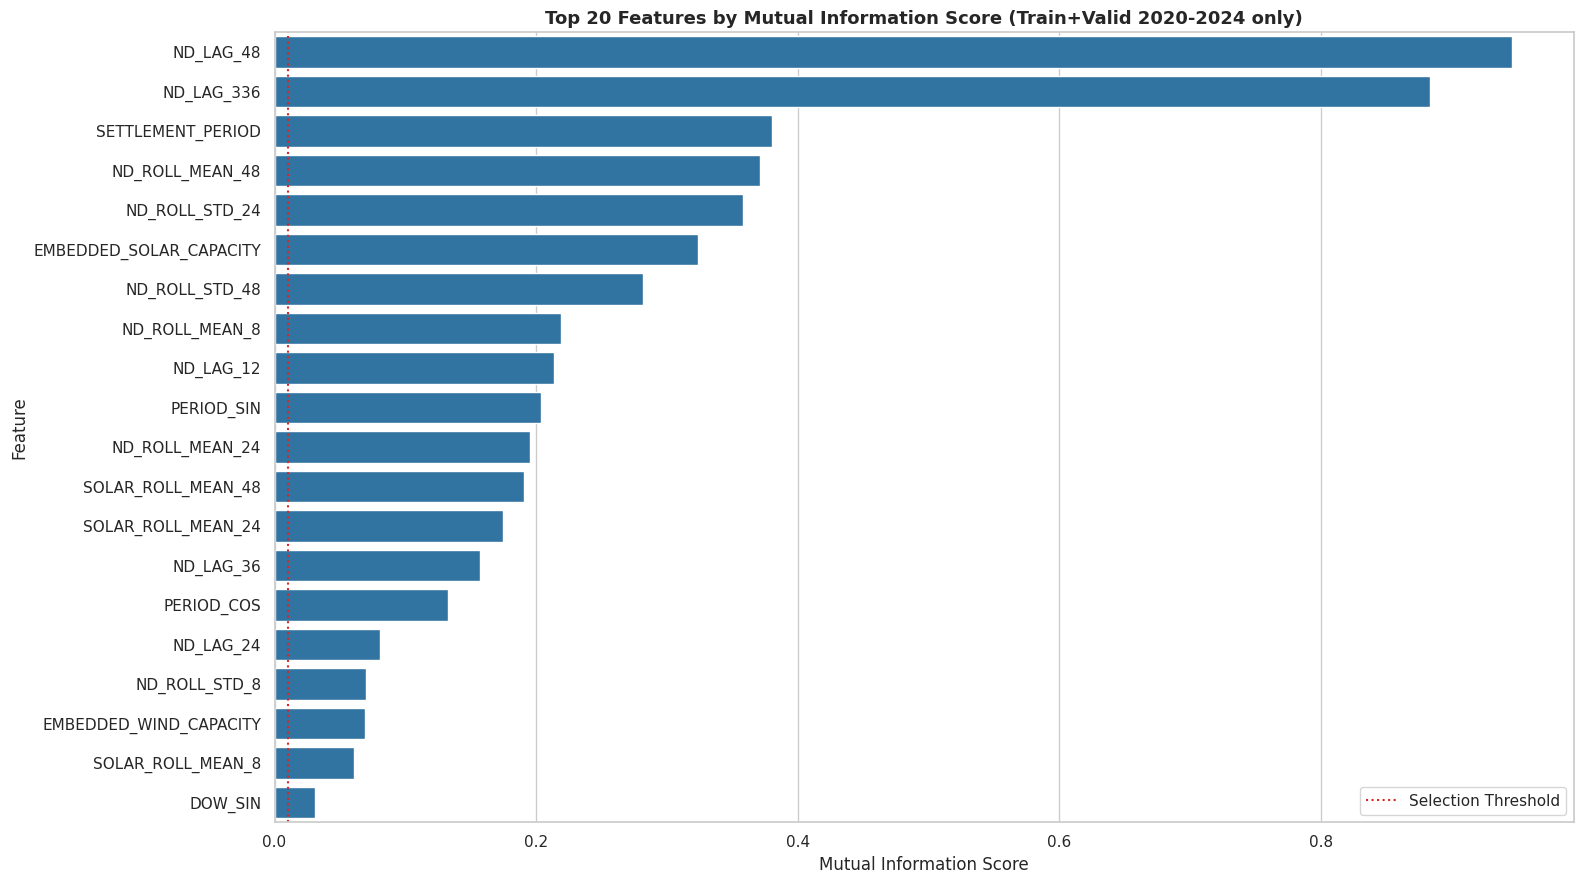

In [10]:
BIEN_MUC_TIEU_CHINH = "ND"
CAC_COT_MUC_TIEU_GIU_LAI = ["ND", "TSD", "ENGLAND_WALES_DEMAND"]

cac_cot_ung_vien = [c for c in df_trimmed.columns if c not in CAC_COT_MUC_TIEU_GIU_LAI]
print(f"So cot ung vien dua vao bo loc thong tin tuong ho (khong bao gom ba cot muc tieu): {len(cac_cot_ung_vien)}")


NGAY_NIEM_PHONG_TEST = "2024-12-31 23:30:00"
df_mi_pool = df_trimmed.loc[:NGAY_NIEM_PHONG_TEST]
so_dong_bi_niem_phong = df_trimmed.shape[0] - df_mi_pool.shape[0]
print(f"Kich thuoc vung du lieu dung de tinh MI (chi 2020-2024, da niem phong Test): {df_mi_pool.shape}")
print(f"So dong thuoc nam 2025 bi loai khoi buoc tinh MI de tranh ro ri: {so_dong_bi_niem_phong:,}")

N_MAU = 15000
mau_ngau_nhien = df_mi_pool.sample(n=N_MAU, random_state=42)

X_mau = mau_ngau_nhien[cac_cot_ung_vien]
y_mau = mau_ngau_nhien[BIEN_MUC_TIEU_CHINH]

diem_mi = mutual_info_regression(X_mau, y_mau, random_state=42)
bang_mi = (pd.DataFrame({"Dac trung": cac_cot_ung_vien, "Diem MI": diem_mi})
             .sort_values("Diem MI", ascending=False)
             .reset_index(drop=True))

print(f"\nDa tinh diem thong tin tuong ho tren mau ngau nhien N={N_MAU:,} quan trac (chi trong giai doan 2020-2024), doi chieu voi bien muc tieu {BIEN_MUC_TIEU_CHINH}.")
print("\n10 dac trung co diem thong tin tuong ho cao nhat:")
print(bang_mi.head(10))
print("\n10 dac trung co diem thong tin tuong ho thap nhat:")
print(bang_mi.tail(10))

NGUONG_MI = 0.01
cot_bi_loai = bang_mi[bang_mi["Diem MI"] <= NGUONG_MI]["Dac trung"].tolist()
cot_duoc_giu = bang_mi[bang_mi["Diem MI"] > NGUONG_MI]["Dac trung"].tolist()

print(f"\nNguong chon loc: diem MI phai lon hon {NGUONG_MI}.")
print(f"So dac trung bi loai bo (truoc khi bao ve cap tuan hoan / cot bat buoc): {len(cot_bi_loai)}")
print(f"So dac trung duoc giu lai (truoc khi bao ve): {len(cot_duoc_giu)}")

# SUA: bao ve cap tuan hoan sin/cos. Bo loc MI cham diem tung
# cot MOT CACH DOC LAP nen co the giu DOW_SIN ma bo DOW_COS (hoac nguoc lai), lam
# ma hoa tuan hoan mat tinh don anh: rieng mot nua cap khong the phan biet duoc het
# 7 ngay trong tuan (hay 48 chu ky trong ngay). Neu mot nua cap vuot nguong thi giu
# ca hai. Doi chieu CYCLICAL_FEATURE_GROUPS trong src/demandforecast/config.py.
CAC_CAP_TUAN_HOAN = [["PERIOD_SIN", "PERIOD_COS"], ["DOW_SIN", "DOW_COS"]]
cot_duoc_giu_set = set(cot_duoc_giu)
cot_bi_loai_set = set(cot_bi_loai)
for cap in CAC_CAP_TUAN_HOAN:
    cap_ton_tai = [c for c in cap if c in cac_cot_ung_vien]
    if cap_ton_tai and any(c in cot_duoc_giu_set for c in cap_ton_tai):
        for c in cap_ton_tai:
            cot_duoc_giu_set.add(c)
            cot_bi_loai_set.discard(c)

# SUA: mot so cot bat buoc phai giu vi ly do CAU TRUC (buoc suy luan sau nay
# can den), khong phai vi diem MI -- SETTLEMENT_PERIOD can thiet de tai tao lai
# PERIOD_SIN/PERIOD_COS tai thoi diem suy luan (inference). Doi chieu
# MUTUAL_INFO_PROTECTED_COLUMNS trong config.py.
CAC_COT_BAT_BUOC_GIU = ["SETTLEMENT_PERIOD"]
for c in CAC_COT_BAT_BUOC_GIU:
    if c in cac_cot_ung_vien:
        cot_duoc_giu_set.add(c)
        cot_bi_loai_set.discard(c)

cot_duoc_giu = [f for f in bang_mi["Dac trung"] if f in cot_duoc_giu_set]
cot_bi_loai = [f for f in bang_mi["Dac trung"] if f in cot_bi_loai_set]

print(f"\nSau khi bao ve cap tuan hoan + cot cau truc bat buoc:")
print(f"So dac trung duoc giu lai: {len(cot_duoc_giu)}")
print(f"So dac trung bi loai bo: {len(cot_bi_loai)}")
if len(cot_bi_loai) > 0:
    print("\nDanh sach dac trung bi loai bo:")
    print(cot_bi_loai)

plt.figure(figsize=(16, 9))
top_ve = bang_mi.head(20)
sns.barplot(data=top_ve, y="Dac trung", x="Diem MI", color="tab:blue")
plt.axvline(NGUONG_MI, color="tab:red", linestyle=":", linewidth=1.5, label="Selection Threshold")
plt.title("Top 20 Features by Mutual Information Score (Train+Valid 2020-2024 only)")
plt.xlabel("Mutual Information Score")
plt.ylabel("Feature")
plt.legend()
plt.tight_layout()
plt.show()


**Nhận xét**

Về mặt định tính, kỳ vọng vẫn giữ nguyên: nhóm đặc trưng trễ ngắn hạn độ 1 và độ 2 của cả ba chuỗi mục tiêu nên tiếp tục chiếm các vị trí dẫn đầu về điểm thông tin tương hỗ, phù hợp với phát hiện quán tính tự hồi quy mạnh ở các độ trễ đầu tiên đã trình bày trong phân tích PACF của notebook 02_eda.ipynb. Quan sát về DOW_COS so với DOW_SIN (góc pha neo tại thứ Hai khiến thành phần cos mang ít thông tin phân biệt hơn) vẫn có giá trị diễn giải độc lập với việc sửa lỗi rò rỉ, nhưng cần đối chiếu lại xem cột này còn nằm dưới ngưỡng 0,01 sau khi tính lại hay không.

Cần lưu ý rằng dù `ND_LAG_48` và `ND_LAG_336` đóng vai trò công thức của hai đường cơ sở SNaive, cả hai vẫn được giữ nguyên trong tập đặc trưng cho các mô hình học máy (nếu vượt ngưỡng chọn lọc MI sau khi tính lại), vì bản thân chúng cũng là những đặc trưng dự báo mạnh cho Linear Regression, Random Forest, XGBoost và LightGBM, không chỉ đơn thuần là mốc so sánh.

## Part 7: Kiểm tra tính năng suất và xuất csv chính

### 7.1 Khối lệnh nghiệm thu gatekeeper

Trước khi lưu ma trận đặc trưng cuối cùng ra đĩa, ta thực hiện một khối kiểm tra nghiệm thu bắt buộc nhằm xác nhận:
* (1) ba thuộc tính mục tiêu lõi ND, TSD và ENGLAND_WALES_DEMAND
được bảo toàn tại các vị trí dẫn đầu của ma trận
* (2) ma trận cấu trúc không còn chứa bất kỳ giá trị trống nào
* (3) toàn bộ đặc trưng còn lại đều đã đi qua bộ lọc thông tin tương hỗ ở phần 06.

In [11]:
cot_cuoi_cung = CAC_COT_MUC_TIEU_GIU_LAI + cot_duoc_giu
df_final = df_trimmed[cot_cuoi_cung].copy()

print("KHOI LENH NGHIEM THU GATEKEEPER")
print("=" * 55)

vi_tri_dung = list(df_final.columns[:3])
assert vi_tri_dung == CAC_COT_MUC_TIEU_GIU_LAI, "Ba cot muc tieu khong nam dung vi tri dan dau!"
print(f"[OK] Ba cot muc tieu {CAC_COT_MUC_TIEU_GIU_LAI} duoc bao toan tai vi tri dan dau ma tran.")

so_o_trong_cuoi = int(df_final.isna().sum().sum())
assert so_o_trong_cuoi == 0, "Ma tran cuoi cung van con o trong!"
print(f"[OK] Ma tran cau truc khong con o trong nao (tong o trong = {so_o_trong_cuoi}).")

so_cot_khong_so_cuoi = df_final.select_dtypes(exclude=[np.number]).shape[1]
assert so_cot_khong_so_cuoi == 0, "Van con cot khong phai kieu so!"
print(f"[OK] Toan bo {df_final.shape[1]} cot deu thuoc kieu so thuan tuy.")

assert set(cot_duoc_giu).isdisjoint(set(cot_bi_loai))
print(f"[OK] Toan bo {len(cot_duoc_giu)} dac trung con lai deu da duoc kiem dinh bang bo loc thong tin tuong ho.")

# SUA (dot 2): kiem tra bo sung -- ro ri chan troi da duoc loai bo, va cap tuan
# hoan DOW_SIN/DOW_COS khong bi cat doi.
cac_cot_ro_ri_con_sot = [c for c in CAC_COT_NGOAI_SINH_RO_RI if c in df_final.columns]
assert not cac_cot_ro_ri_con_sot, f"Cac cot ro ri chan troi van con sot lai: {cac_cot_ro_ri_con_sot}!"
print("[OK] Khong con cot ngoai sinh ro ri chan troi (do tai thoi diem t) nao trong ma tran cuoi cung.")

if ("DOW_SIN" in df_final.columns) or ("DOW_COS" in df_final.columns):
    assert ("DOW_SIN" in df_final.columns) == ("DOW_COS" in df_final.columns), "Cap tuan hoan DOW_SIN/DOW_COS bi cat doi!"
    print("[OK] Cap tuan hoan DOW_SIN/DOW_COS con nguyen ven (ca hai cung co mat hoac cung vang mat).")

assert "SETTLEMENT_PERIOD" in df_final.columns, "SETTLEMENT_PERIOD (cot bat buoc) bi thieu!"
print("[OK] SETTLEMENT_PERIOD (cot cau truc bat buoc cho inference) co mat trong ma tran cuoi cung.")

assert not any(c.startswith("TSD_LAG") or c.startswith("ENGLAND_WALES_DEMAND_LAG") for c in df_final.columns), \
    "Van con cot lag cua TSD/ENGLAND_WALES_DEMAND -- AR_LAG_TARGETS phai chi la ND!"
print("[OK] Khong con cot lag nao cua TSD/ENGLAND_WALES_DEMAND (chi ND duoc lag).")

print(f"\n>>> TAT CA KIEM TRA NGHIEM THU DEU DAT. Kich thuoc ma tran dac trung cuoi cung: {df_final.shape}")


KHOI LENH NGHIEM THU GATEKEEPER
[OK] Ba cot muc tieu ['ND', 'TSD', 'ENGLAND_WALES_DEMAND'] duoc bao toan tai vi tri dan dau ma tran.
[OK] Ma tran cau truc khong con o trong nao (tong o trong = 0).
[OK] Toan bo 25 cot deu thuoc kieu so thuan tuy.
[OK] Toan bo 22 dac trung con lai deu da duoc kiem dinh bang bo loc thong tin tuong ho.
[OK] Khong con cot ngoai sinh ro ri chan troi (do tai thoi diem t) nao trong ma tran cuoi cung.
[OK] Cap tuan hoan DOW_SIN/DOW_COS con nguyen ven (ca hai cung co mat hoac cung vang mat).
[OK] SETTLEMENT_PERIOD (cot cau truc bat buoc cho inference) co mat trong ma tran cuoi cung.
[OK] Khong con cot lag nao cua TSD/ENGLAND_WALES_DEMAND (chi ND duoc lag).

>>> TAT CA KIEM TRA NGHIEM THU DEU DAT. Kich thuoc ma tran dac trung cuoi cung: (104880, 25)


### 7.2 Xuất ma trận đặc trưng hoàn chỉnh

Ma trận đặc trưng cuối cùng được lưu ra đĩa dưới tên `electricity_features.csv`, với chỉ mục DATETIME được giữ nguyên làm cột tham chiếu thời gian. Tệp này sẽ là đầu vào tiêu chuẩn duy nhất cho notebook huấn luyện và đánh giá mô hình tiếp theo.

In [12]:
OUT_PATH = "electricity_features_fixed.csv"
df_final.to_csv(OUT_PATH, index=True, index_label="DATETIME")
print(f"Da luu ma tran dac trung hoan chinh tai: {OUT_PATH}")
print(f"Kich thuoc tep cuoi cung: {df_final.shape}")
print(f"Giai doan thoi gian: {df_final.index.min()} den {df_final.index.max()}")
print("\n5 dong dau:")
df_final.head()


Da luu ma tran dac trung hoan chinh tai: electricity_features_fixed.csv
Kich thuoc tep cuoi cung: (104880, 25)
Giai doan thoi gian: 2020-01-08 00:00:00 den 2025-12-31 23:30:00

5 dong dau:


,ND,TSD,ENGLAND_WALES_DEMAND,ND_LAG_48,ND_LAG_336,SETTLEMENT_PERIOD,ND_ROLL_MEAN_48,ND_ROLL_STD_24,EMBEDDED_SOLAR_CAPACITY,ND_ROLL_STD_48,ND_ROLL_MEAN_8,ND_LAG_12,PERIOD_SIN,ND_ROLL_MEAN_24,SOLAR_ROLL_MEAN_48,SOLAR_ROLL_MEAN_24,ND_LAG_36,PERIOD_COS,ND_LAG_24,ND_ROLL_STD_8,EMBEDDED_WIND_CAPACITY,SOLAR_ROLL_MEAN_8,DOW_SIN,IS_WEEKEND,DOW_COS
DATETIME,,,,,,,,,,,,,,,,,,,,,,,,,
2020-01-08 00:00:00,"22,751.0000","25,625.0000","21,366.0000","25,424.0000","26,340.0000",1,"33,176.1875","2,333.5146","13,042.0000","6,297.2861","39,583.2500","40,529.0000",0.1305,"37,433.6250",149.4583,298.9167,"27,669.0000",0.9914,"37,467.0000","1,765.6103","6,465.0000",38.8750,0.9749,0,-0.2225
2020-01-08 00:30:00,"23,123.0000","25,520.0000","21,795.0000","25,967.0000","26,921.0000",2,"33,145.8125","1,860.4485","13,042.0000","6,261.6481","39,890.8750","39,646.0000",0.2588,"37,811.7500",149.4583,298.9167,"30,571.0000",0.9659,"37,283.0000","1,479.2337","6,465.0000",11.1250,0.9749,0,-0.2225
2020-01-08 01:00:00,"22,990.0000","25,742.0000","21,641.0000","25,767.0000","26,569.0000",3,"33,112.5417","1,663.9013","13,042.0000","6,227.1747","40,069.0000","38,666.0000",0.3827,"38,012.4167",149.4583,298.9167,"33,850.0000",0.9239,"37,423.0000","1,167.5114","6,465.0000",0.8750,0.9749,0,-0.2225
2020-01-08 01:30:00,"22,427.0000","25,516.0000","21,134.0000","25,170.0000","25,754.0000",4,"33,067.4375","1,592.4033","13,042.0000","6,188.0796","39,937.2500","37,276.0000",0.5000,"38,081.9167",149.4583,298.9167,"35,608.0000",0.8660,"37,299.0000","1,423.2480","6,465.0000",0.0000,0.9749,0,-0.2225
2020-01-08 02:00:00,"22,167.0000","25,331.0000","20,863.0000","24,535.0000","25,075.0000",5,"33,020.7917","1,620.8809","13,042.0000","6,157.7476","39,450.5000","35,855.0000",0.6088,"38,059.3750",149.4583,298.8333,"36,396.0000",0.7934,"37,240.0000","2,032.3584","6,465.0000",0.0000,0.9749,0,-0.2225


### Tổng kết notebook

**Nhận xét kết luận**

Notebook này đã hoàn thiện toàn bộ chuỗi công đoạn từ nạp dữ liệu sạch, xây dựng đặc trưng trễ và đặc trưng trượt, mã hoá toạ độ tuần hoàn, **loại bỏ 12 cột ngoại sinh đo tại thời điểm t (rò rỉ chân trời, Part 4.2)**, cắt biên và tinh lọc cấu trúc ma trận, cho đến chọn lọc đặc trưng bằng thông tin tương hỗ (nay có **bảo vệ cặp tuần hoàn sin/cos và cột cấu trúc bắt buộc**, Part 6.1) và xuất tệp cuối cùng dưới tên **`electricity_features_fixed.csv`** (không phải `electricity_features_lag12.csv` của đợt sửa trước, để tránh nhầm lẫn với bản còn rò rỉ). Khác với đợt sửa trước, chuỗi ND là chuỗi **duy nhất** được tạo đặc trưng trễ (TSD và ENGLAND_WALES_DEMAND không còn cột `_LAG_*` nữa), và số cột đặc trưng dự kiến giảm mạnh so với bản cũ (khoảng 43→25 cột theo lần chạy thật trên dữ liệu đầy đủ) con số chính xác sẽ được in ra ở ô lệnh gatekeeper (Part 7.1) khi chạy lại notebook này trên máy có đủ dữ liệu raw. Toàn bộ quy trình vẫn tuân thủ nghiêm ngặt nguyên tắc phòng chống rò rỉ dữ liệu (dịch lùi trước mọi phép tính trượt, niêm phong tập Test khi tính MI), và nay thêm một lớp phòng chống rò rỉ thứ hai ở phía **ngoại sinh** (không chỉ tự hồi quy).

Ma trận này sẽ được nạp trực tiếp làm đầu vào cho `notebook 04_model_training_and_evaluation_revised.ipynb` (đã cập nhật để đọc `electricity_features_fixed.csv`), nơi các mô hình dự báo hai đường cơ sở mùa vụ ngây thơ **SNaive Daily** (đọc trực tiếp cột `ND_LAG_48`) và **SNaive Weekly** (đọc trực tiếp cột `ND_LAG_336`), cùng với Linear Regression, Random Forest, XGBoost, LightGBM và nay thêm **CatBoost** sẽ được huấn luyện và đối chiếu trên cùng một tập đặc trưng đã được vá rò rỉ này. **Lưu ý:** vì đã loại bỏ thông tin không có thật tại thời điểm ra quyết định, MAPE trên tập Test 2025 của mọi mô hình dự kiến sẽ **cao hơn** con số 3,59% đã công bố trước đây đây là đặc điểm mong đợi của việc vá rò rỉ, không phải lỗi của lần huấn luyện mới.
